# Kushagra Singh 2401PH07

# Q1

Enter value of n between 1 and 5:  4


Degree of Polynomial = 4
Interpolated Energy = -0.85 eV


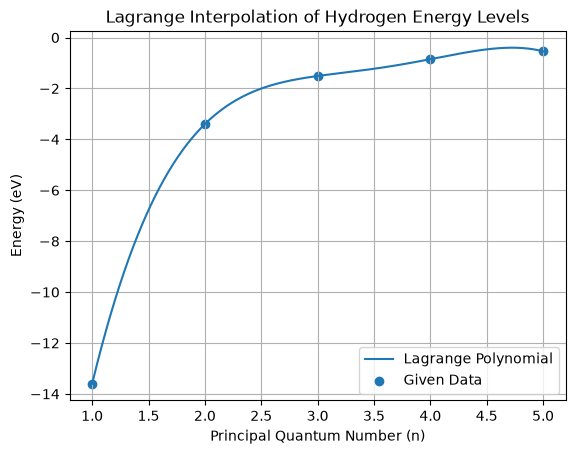

In [53]:
import matplotlib.pyplot as plt


X = [1, 2, 3, 4, 5]
Y = [-13.6, -3.40, -1.51, -0.85, -0.54]

# Lagrange Interpolation
def lagrange_interpolation(x, X, Y, degree):
    result = 0

    for k in range(degree + 1):
        L = 1

        for i in range(degree + 1):
            if i != k:
                L = L * (x - X[i]) / (X[k] - X[i])

        result = result + L * Y[k]

    return result



x = float(input("Enter value of n between 1 and 5: "))


degree = 4

value = lagrange_interpolation(x, X, Y, degree)

print("Degree of Polynomial =", degree)
print("Interpolated Energy =", value, "eV")




x_values = []
y_values = []

for i in range(1, 501):
    x_val = 1 + (i - 1) * (4 / 499)
    x_values.append(x_val)
    y_values.append(lagrange_interpolation(x_val, X, Y, degree))

plt.plot(x_values, y_values, label="Lagrange Polynomial")
plt.scatter(X, Y, label="Given Data")

plt.title("Lagrange Interpolation of Hydrogen Energy Levels")
plt.xlabel("Principal Quantum Number (n)")
plt.ylabel("Energy (eV)")
plt.grid()
plt.legend()
plt.show()


# Q2 

Forward Difference Table
------------------------------------------
0	0.0	0.173648	-0.005276	-0.005116	0.000316	
10	0.173648	0.168372	-0.010392	-0.0048	
20	0.34202	0.15798	-0.015192	
30	0.5	0.142788	
40	0.642788	

Results
------------------------------------------
Theta = 75 degrees
Interpolated value = 0.9610113076633365
Actual value       = 0.9659258262890683
Error              = 0.0049145186257317786


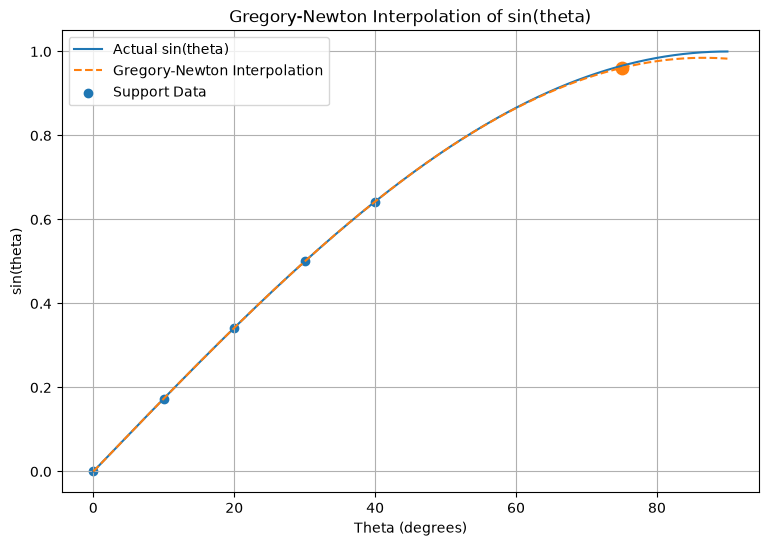

In [55]:
import math
import matplotlib.pyplot as plt

x = [0, 10, 20, 30, 40]

y = []

for i in range(len(x)):
    y.append(math.sin(math.radians(x[i])))

h = 10
n = len(x)



diff = [[0 for j in range(n)] for i in range(n)]

# First column = function values
for i in range(n):
    diff[i][0] = y[i]

# Calculate differences
for j in range(1, n):
    for i in range(n - j):
        diff[i][j] = diff[i + 1][j - 1] - diff[i][j - 1]

# Display difference table
print("Forward Difference Table")
print("------------------------------------------")

for i in range(n):
    print(x[i], end="\t")

    for j in range(n - i):
        print(round(diff[i][j], 6), end="\t")

    print()




def gregory_newton(x_value):

    p = (x_value - x[0]) / h

    value = diff[0][0]
    term = 1

    for k in range(1, n):
        term = term * (p - (k - 1)) / k
        value = value + term * diff[0][k]

    return value


# ---------------------------------------
# FIND sin(35°)
# ---------------------------------------

x_target = 75

interpolated_value = gregory_newton(x_target)

actual_value = math.sin(math.radians(x_target))

print("\nResults")
print("------------------------------------------")
print("Theta =", x_target, "degrees")
print("Interpolated value =", interpolated_value)
print("Actual value       =", actual_value)
print("Error              =", abs(actual_value - interpolated_value))




x_curve = []
y_curve = []

x_value = 0

while x_value <= 90:

    x_curve.append(x_value)

    # Calculate interpolated value
    value = gregory_newton(x_value)

    y_curve.append(value)

    x_value = x_value + 0.1




x_actual = []
y_actual = []

x_value = 0

while x_value <= 90:

    x_actual.append(x_value)

    y_actual.append(
        math.sin(math.radians(x_value))
    )

    x_value = x_value + 0.1




plt.figure(figsize=(9, 6))

# Actual sin(x)
plt.plot(
    x_actual,
    y_actual,
    label="Actual sin(theta)"
)

# Gregory-Newton interpolation curve
plt.plot(
    x_curve,
    y_curve,
    '--',
    label="Gregory-Newton Interpolation"
)

# Original support points
plt.scatter(
    x,
    y,
    label="Support Data"
)


plt.scatter(
    x_target,
    interpolated_value,
    s=80,
  #  label="Interpolated at 35°"
)

plt.xlabel("Theta (degrees)")
plt.ylabel("sin(theta)")

plt.title("Gregory-Newton Interpolation of sin(theta)")

plt.grid(True)
plt.legend()

plt.show()

# Q3

Neville's Interpolation
-----------------------------
x = 0 Probability = 0.5641
x = 0.5 Probability = 0.4394
x = 1.0 Probability = 0.2075
x = 1.5 Probability = 0.0594
x = 2.0 Probability = 0.10323
x = 2.5 Probability = 0.364248
x = 3.0 Probability = 0.784843


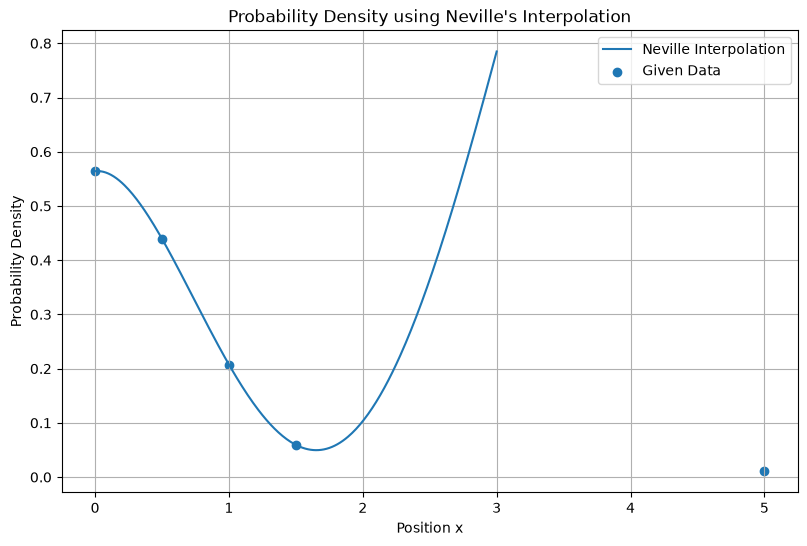


Neville Interpolation Table
----------------------------------------------------------
i	Q(i,0)		Q(i,1)		Q(i,2)		Q(i,3)		Q(i,4)
----------------------------------------------------------
0	0.564100		0.065300		-0.577900		0.186100		0.103230		
1	0.439400		-0.256300		-0.004900		-0.021076		
2	0.207500		-0.088700		-0.053429		
3	0.059400		0.052386		
4	0.010300		


In [58]:
import matplotlib.pyplot as plt


x = [0, 0.5, 1, 1.5, 5]
y = [0.5641, 0.4394, 0.2075, 0.0594, 0.0103]




def neville(x_data, y_data, x_value):

    n = len(x_data)

    Q = [[0 for j in range(n)] for i in range(n)]

    
    for i in range(n):
        Q[i][0] = y_data[i]

    
    for j in range(1, n):
        for i in range(n - j):

            Q[i][j] = (
                (x_value - x_data[i + j]) * Q[i][j - 1]
                + (x_data[i] - x_value) * Q[i + 1][j - 1]
            ) / (x_data[i] - x_data[i + j])

    return Q[0][n - 1]




x_plot = []
y_plot = []

#  step = 0.01
x_value = 0

while x_value <= 3:

    y_value = neville(x, y, x_value)

    x_plot.append(x_value)
    y_plot.append(y_value)

    x_value = x_value + 0.01




print("Neville's Interpolation")
print("-----------------------------")

for i in range(0, len(x_plot), 50):
    print("x =", round(x_plot[i], 2),
          "Probability =", round(y_plot[i], 6))


#

plt.figure(figsize=(9.5, 6))


plt.plot(x_plot, y_plot,
         label="Neville Interpolation")


plt.scatter(x, y,
            label="Given Data")

plt.xlabel("Position x")
plt.ylabel("Probability Density")
plt.title("Probability Density using Neville's Interpolation")

plt.grid(True)
plt.legend()

plt.show()

print("\nNeville Interpolation Table")
print("----------------------------------------------------------")
print("i\tQ(i,0)\t\tQ(i,1)\t\tQ(i,2)\t\tQ(i,3)\t\tQ(i,4)")
print("----------------------------------------------------------")

for i in range(n):

    print(i, end="\t")

    for j in range(n - i):
        print(f"{Q[i][j]:.6f}\t\t", end="")

    print()
    

# Q4

BACKWARD DIFFERENCE TABLE
x		f(x)		Δf		Δ²f		Δ³f		Δ⁴f
0.1		9.966644									
0.2		4.933155	-5.033490							
0.3		3.232728	-1.700427	3.333063					
0.4		2.365222	-0.867506	0.832921	-2.500142			
0.5		1.830488	-0.534735	0.332771	-0.500150	1.999992	


VALUE NEAR SINGULARITY
Singularity = x = 0
Target x = 0.05

Lagrange interpolation = 15.061454832629252
Rational interpolation  = 10.004497792495961
Actual cot(0.05)        = 19.983330554894014

ERROR
Lagrange error  = 4.921875722264762
Rational error  = 9.978832762398053


BEHAVIOR NEAR SINGULARITY
x		Actual		Lagrange	Rational
0.50		1.830488	1.830488	1.830488
0.40		2.365222	2.365222	2.320222
0.30		3.232728	3.232728	-301746643847.650513
0.20		4.933155	4.933155	4.908155
0.15		6.616592	6.798883	9.979568
0.10		9.966644	9.966644	9.966644
0.08		12.473322	11.734122	9.974790
0.06		16.646662	13.854128	9.992065
0.05		19.983331	15.061455	10.004498


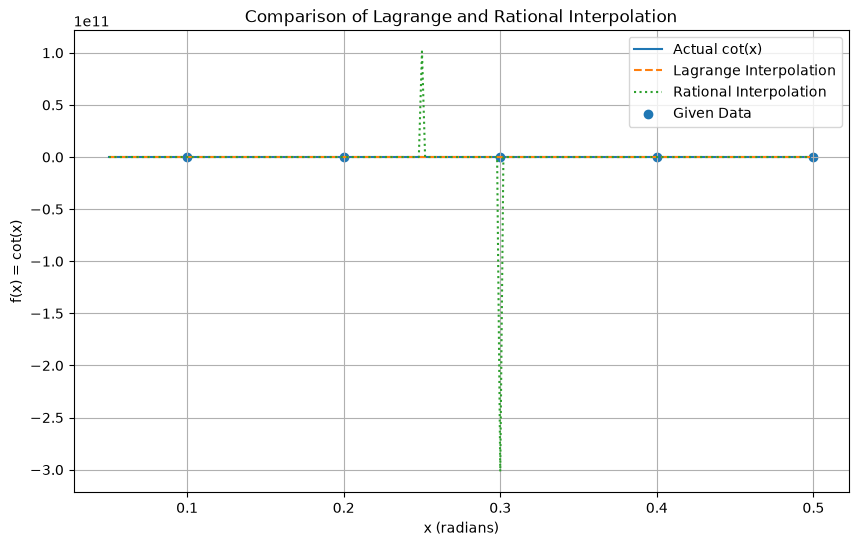

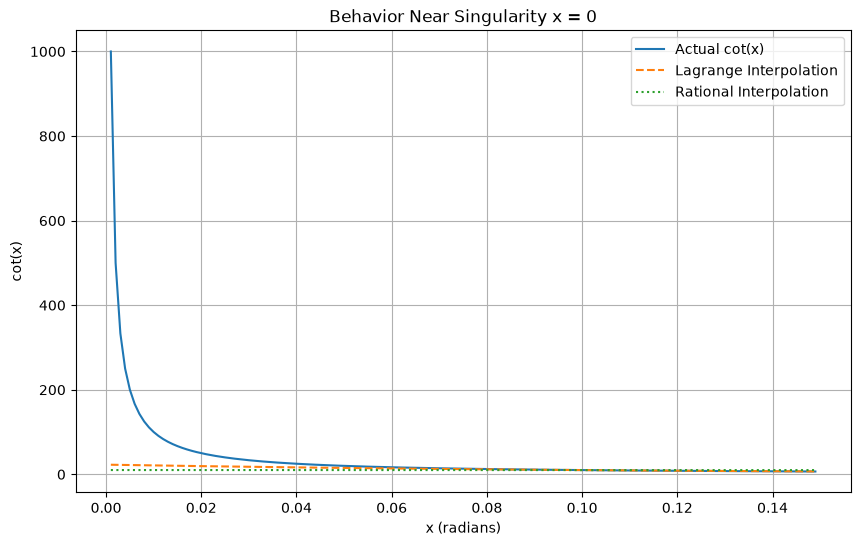

In [62]:
import math
import matplotlib.pyplot as plt


def cot(x):
    return 1 / math.tan(x)


x = [0.1, 0.2, 0.3, 0.4, 0.5]

y = []

for i in range(len(x)):
    y.append(cot(x[i]))


n = len(x)

diff = [[0 for j in range(n)] for i in range(n)]

for i in range(n):
    diff[i][0] = y[i]


for j in range(1, n):
    for i in range(j, n):
        diff[i][j] = diff[i][j - 1] - diff[i - 1][j - 1]


print("BACKWARD DIFFERENCE TABLE")
print("==========================================================")

print("x\t\tf(x)\t\tΔf\t\tΔ²f\t\tΔ³f\t\tΔ⁴f")

for i in range(n):

    print(f"{x[i]:.1f}\t\t", end="")

    for j in range(n):

        if j <= i:
            print(f"{diff[i][j]:.6f}\t", end="")
        else:
            print("\t\t", end="")

    print()


def lagrange_interpolation(x_data, y_data, x_value):

    result = 0.0
    n = len(x_data)

    for i in range(n):

        term = y_data[i]

        for j in range(n):

            if i != j:
                term = term * (
                    (x_value - x_data[j]) /
                    (x_data[i] - x_data[j])
                )

        result = result + term

    return result


def rational_interpolation(x_data, y_data, x_value):

    n = len(x_data)

    c = y_data[:]
    d = y_data[:]

    ns = 0
    closest = abs(x_value - x_data[0])

    for i in range(1, n):

        distance = abs(x_value - x_data[i])

        if distance < closest:
            ns = i
            closest = distance

    result = y_data[ns]

    ns = ns - 1

    for m in range(1, n):

        for i in range(n - m):

            ho = x_data[i] - x_value
            hp = x_data[i + m] - x_value

            w = c[i + 1] - d[i]

            denominator = (
                ho * d[i + 1] -
                hp * c[i]
            )

            if abs(w) < 1e-14:
                w = 1e-14

            factor = denominator / w

            d[i] = hp * factor
            c[i] = ho * factor

        if 2 * (ns + 1) < (n - m):

            result = result + c[ns + 1]

        else:

            result = result + d[ns]

            ns = ns - 1

    return result


x_target = 0.05

lagrange_value = lagrange_interpolation(
    x,
    y,
    x_target
)

rational_value = rational_interpolation(
    x,
    y,
    x_target
)

actual_value = cot(x_target)


print("\n\nVALUE NEAR SINGULARITY")
print("==========================================================")

print("Singularity = x = 0")
print("Target x =", x_target)

print("\nLagrange interpolation =", lagrange_value)

print("Rational interpolation  =", rational_value)

print("Actual cot(0.05)        =", actual_value)


lagrange_error = abs(
    actual_value - lagrange_value
)

rational_error = abs(
    actual_value - rational_value
)


print("\nERROR")
print("==========================================================")

print("Lagrange error  =", lagrange_error)

print("Rational error  =", rational_error)


print("\n\nBEHAVIOR NEAR SINGULARITY")
print("==========================================================")

print(
    "x\t\tActual\t\tLagrange\tRational"
)


test_values = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.15,
    0.10,
    0.08,
    0.06,
    0.05
]


for value in test_values:

    actual = cot(value)

    lagrange = lagrange_interpolation(
        x,
        y,
        value
    )

    rational = rational_interpolation(
        x,
        y,
        value
    )

    print(
        f"{value:.2f}\t\t"
        f"{actual:.6f}\t"
        f"{lagrange:.6f}\t"
        f"{rational:.6f}"
    )


x_plot = []

actual_plot = []

lagrange_plot = []

rational_plot = []


x_value = 0.05

while x_value <= 0.5:

    x_plot.append(x_value)

    actual_plot.append(
        cot(x_value)
    )

    lagrange_plot.append(
        lagrange_interpolation(
            x,
            y,
            x_value
        )
    )

    rational_plot.append(
        rational_interpolation(
            x,
            y,
            x_value
        )
    )

    x_value = x_value + 0.002


plt.figure(figsize=(10, 6))

plt.plot(
    x_plot,
    actual_plot,
    label="Actual cot(x)"
)

plt.plot(
    x_plot,
    lagrange_plot,
    '--',
    label="Lagrange Interpolation"
)

plt.plot(
    x_plot,
    rational_plot,
    ':',
    label="Rational Interpolation"
)

plt.scatter(
    x,
    y,
    label="Given Data"
)

plt.xlabel("x (radians)")

plt.ylabel("f(x) = cot(x)")

plt.title(
    "Comparison of Lagrange and Rational Interpolation"
)

plt.grid(True)

plt.legend()

plt.show()


x_plot = []

actual_plot = []

lagrange_plot = []

rational_plot = []


x_value = 0.001

while x_value <= 0.15:

    x_plot.append(x_value)

    actual_plot.append(
        cot(x_value)
    )

    lagrange_plot.append(
        lagrange_interpolation(
            x,
            y,
            x_value
        )
    )

    rational_plot.append(
        rational_interpolation(
            x,
            y,
            x_value
        )
    )

    x_value = x_value + 0.001


plt.figure(figsize=(10, 6))

plt.plot(
    x_plot,
    actual_plot,
    label="Actual cot(x)"
)

plt.plot(
    x_plot,
    lagrange_plot,
    '--',
    label="Lagrange Interpolation"
)

plt.plot(
    x_plot,
    rational_plot,
    ':',
    label="Rational Interpolation"
)

plt.xlabel("x (radians)")

plt.ylabel("cot(x)")

plt.title(
    "Behavior Near Singularity x = 0"
)

plt.grid(True)

plt.legend()

plt.show()

# Error Function for Q 4

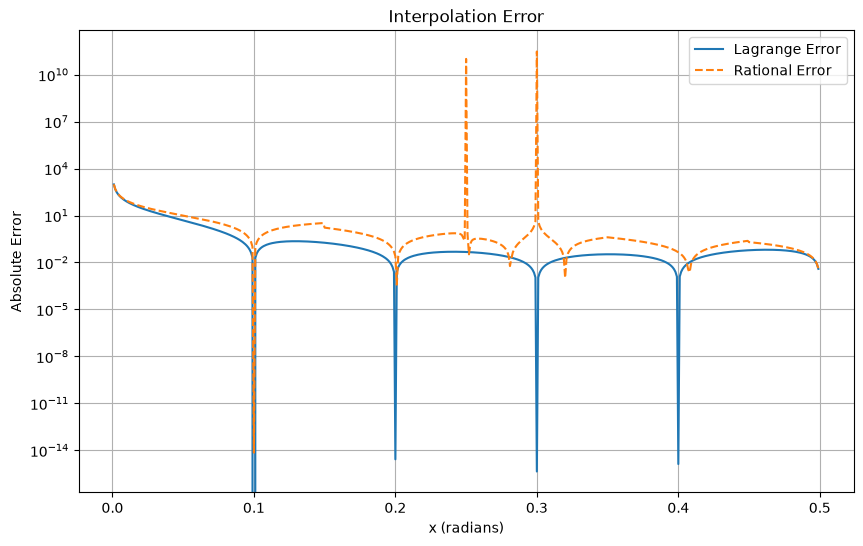

In [63]:
x_error = []

lagrange_error_plot = []

rational_error_plot = []


x_value = 0.001

while x_value <= 0.5:

    actual = cot(x_value)

    lagrange = lagrange_interpolation(
        x,
        y,
        x_value
    )

    rational = rational_interpolation(
        x,
        y,
        x_value
    )

    x_error.append(x_value)

    lagrange_error_plot.append(
        abs(actual - lagrange)
    )

    rational_error_plot.append(
        abs(actual - rational)
    )

    x_value = x_value + 0.001


plt.figure(figsize=(10, 6))

plt.plot(
    x_error,
    lagrange_error_plot,
    label="Lagrange Error"
)

plt.plot(
    x_error,
    rational_error_plot,
    '--',
    label="Rational Error"
)

plt.xlabel("x (radians)")

plt.ylabel("Absolute Error")

plt.title(
    "Interpolation Error"
)

plt.yscale("log")

plt.grid(True)

plt.legend()

plt.show()

# Q4 Comparison curve over a range

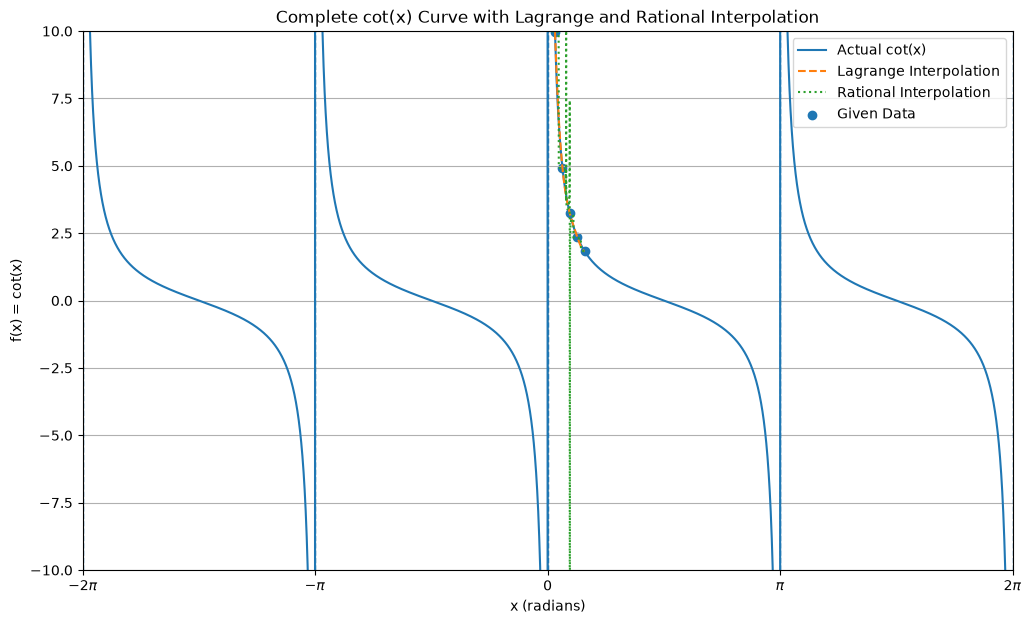

In [65]:
import math
import matplotlib.pyplot as plt


def cot(x):
    return 1 / math.tan(x)


x = [0.1, 0.2, 0.3, 0.4, 0.5]

y = []

for i in range(len(x)):
    y.append(cot(x[i]))


def lagrange_interpolation(x_data, y_data, x_value):

    result = 0.0
    n = len(x_data)

    for i in range(n):

        term = y_data[i]

        for j in range(n):

            if i != j:

                term = term * (
                    (x_value - x_data[j]) /
                    (x_data[i] - x_data[j])
                )

        result = result + term

    return result


def rational_interpolation(x_data, y_data, x_value):

    n = len(x_data)

    c = y_data[:]
    d = y_data[:]

    ns = 0
    closest = abs(x_value - x_data[0])

    for i in range(1, n):

        distance = abs(x_value - x_data[i])

        if distance < closest:

            ns = i
            closest = distance

    result = y_data[ns]

    ns = ns - 1

    for m in range(1, n):

        for i in range(n - m):

            ho = x_data[i] - x_value
            hp = x_data[i + m] - x_value

            w = c[i + 1] - d[i]

            denominator = (
                ho * d[i + 1] -
                hp * c[i]
            )

            if abs(w) < 1e-14:

                w = 1e-14

            factor = denominator / w

            d[i] = hp * factor
            c[i] = ho * factor

        if 2 * (ns + 1) < (n - m):

            result = result + c[ns + 1]

        else:

            result = result + d[ns]

            ns = ns - 1

    return result


x_plot = []
actual_plot = []

start = -2 * math.pi
end = 2 * math.pi
step = 0.002

x_value = start

while x_value <= end:

    if abs(math.sin(x_value)) > 1e-8:

        x_plot.append(x_value)
        actual_plot.append(cot(x_value))

    else:

        x_plot.append(x_value)
        actual_plot.append(float("nan"))

    x_value = x_value + step


x_interp = []
lagrange_plot = []
rational_plot = []

x_value = 0.05

while x_value <= 0.5:

    x_interp.append(x_value)

    lagrange_plot.append(
        lagrange_interpolation(
            x,
            y,
            x_value
        )
    )

    rational_plot.append(
        rational_interpolation(
            x,
            y,
            x_value
        )
    )

    x_value = x_value + 0.001


plt.figure(figsize=(12, 7))

plt.plot(
    x_plot,
    actual_plot,
    label="Actual cot(x)"
)

plt.plot(
    x_interp,
    lagrange_plot,
    "--",
    label="Lagrange Interpolation"
)

plt.plot(
    x_interp,
    rational_plot,
    ":",
    label="Rational Interpolation"
)

plt.scatter(
    x,
    y,
    label="Given Data"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    math.pi,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    -math.pi,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    2 * math.pi,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    -2 * math.pi,
    linestyle="--",
    linewidth=1
)

plt.xlim(
    -2 * math.pi,
    2 * math.pi
)

plt.ylim(
    -10,
    10
)

plt.xticks(
    [
        -2 * math.pi,
        -math.pi,
        0,
        math.pi,
        2 * math.pi
    ],
    [
        r"$-2\pi$",
        r"$-\pi$",
        "0",
        r"$\pi$",
        r"$2\pi$"
    ]
)

plt.xlabel("x (radians)")

plt.ylabel("f(x) = cot(x)")

plt.title(
    "Complete cot(x) Curve with Lagrange and Rational Interpolation"
)

plt.grid(True)

plt.legend()

plt.show()